# S11685 Final Project — Baseline DMN Training (Colab)

**Repository:** [billliu-cmd/S11685_Final_Project](https://github.com/billliu-cmd/S11685_Final_Project)

This notebook:
1. Clones the repository
2. Downloads 21 ETFs from yfinance and builds the feature panel
3. Trains the **Baseline DMN** (VSN + LSTM + skip connections) on GPU
4. Evaluates on the held-out test set and runs a backtest

> **GPU Required:** `Runtime → Change runtime type → T4 GPU`

In [1]:
# ── Check GPU & install dependencies ──────────────────────────────────────────
import torch

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected!  Go to Runtime > Change runtime type > T4 GPU"
    )

print(f"\u2705 PyTorch {torch.__version__} | GPU: {torch.cuda.get_device_name(0)}")

!pip install -q yfinance

✅ PyTorch 2.10.0+cu128 | GPU: NVIDIA A100-SXM4-40GB


In [2]:
# ── Clone repository ───────────────────────────────────────────────────────
import os, sys
%cd /content
!rm -rf S11685_Final_Project
!git clone https://github.com/billliu-cmd/S11685_Final_Project.git

# Add to Python path so relative imports work
sys.path.insert(0, "/content")
print()
!ls -la S11685_Final_Project/*.py

/content
Cloning into 'S11685_Final_Project'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (61/61), done.
Receiving objects: 100% (63/63), 32.67 KiB | 8.17 MiB/s, done.
remote: Total 63 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Resolving deltas: 100% (27/27), done.

-rw-r--r-- 1 root root 3480 Mar 11 19:31 S11685_Final_Project/backtest.py
-rw-r--r-- 1 root root  807 Mar 11 19:31 S11685_Final_Project/Baseline.py
-rw-r--r-- 1 root root 4849 Mar 11 19:31 S11685_Final_Project/components.py
-rw-r--r-- 1 root root 1639 Mar 11 19:31 S11685_Final_Project/config.py
-rw-r--r-- 1 root root 8060 Mar 11 19:31 S11685_Final_Project/data.py
-rw-r--r-- 1 root root    1 Mar 11 19:31 S11685_Final_Project/__init__.py
-rw-r--r-- 1 root root 6978 Mar 11 19:31 S11685_Final_Project/train.py


In [ ]:
'''
# import when run on local
from .config import DATA, MODEL, TRAIN
from .data import build_panel, time_split, build_baseline_loaders
from .Baseline import BaselineDMN
from .train import fit, _baseline_step, eval_epoch
from .backtest import run_backtest, compare_equity, print_comparison
'''


In [3]:
# ── Import project modules ─────────────────────────────────────────────────
from S11685_Final_Project.config import DATA, MODEL, TRAIN
from S11685_Final_Project.data import build_panel, time_split, build_baseline_loaders
from S11685_Final_Project.Baseline import BaselineDMN
from S11685_Final_Project.train import fit, _baseline_step, eval_epoch
from S11685_Final_Project.backtest import run_backtest, compare_equity, print_comparison

print("\u2705 All modules imported successfully")

✅ All modules imported successfully


---
## Step 1 — Build Data Panel

In [4]:
import numpy as np, random

# ── Reproducibility ───────────────────────────────────────────────────────
seed = DATA["seed"]
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True

# ── Download & compute features ───────────────────────────────────────────
print("Downloading ETF data & computing features (may take 1-2 min) ...")
panel, fcols, tk2id = build_panel(DATA)
train_d, val_d, test_d = time_split(panel, DATA["train_frac"], DATA["val_frac"])

n_assets = len(tk2id)
n_feat   = len(fcols)

print(f"\n{'='*55}")
print(f"  Assets:     {n_assets}   {list(tk2id.keys())}")
print(f"  Features:   {n_feat}    {fcols}")
print(f"  Date range: {panel['date'].min().date()} \u2192 {panel['date'].max().date()}")
print(f"  Train: {len(train_d):,} days  |  Val: {len(val_d):,} days  |  Test: {len(test_d):,} days")
print(f"{'='*55}")

/content/S11685_Final_Project/data.py:34: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, start=cfg["start"], end=cfg["end"], progress=False)["Close"]



  Assets:     21   ['DBC', 'EEM', 'EFA', 'GLD', 'HYG', 'IEF', 'IWM', 'LQD', 'QQQ', 'SHY', 'SPY', 'TLT', 'UUP', 'VNQ', 'VTI', 'XLE', 'XLF', 'XLI', 'XLK', 'XLP', 'XLV']
  Features:   8    ['norm_ret_1', 'norm_ret_21', 'norm_ret_63', 'norm_ret_126', 'norm_ret_252', 'macd_8_24', 'macd_16_28', 'macd_32_96']
  Date range: 2007-04-11 → 2025-12-29
  Train: 3,297 days  |  Val: 707 days  |  Test: 707 days


In [5]:
# ── DataLoaders ────────────────────────────────────────────────────────────
_, loaders = build_baseline_loaders(panel, fcols, train_d, val_d, test_d, DATA)

print(f"Train batches: {len(loaders['train'])}   (batch_size={DATA['batch_size']})")
print(f"Val   batches: {len(loaders['val'])}")
print(f"Test  batches: {len(loaders['test'])}")

# Sanity check — peek at one batch
batch = next(iter(loaders["train"]))
print(f"\nSample batch shapes:")
print(f"  x:      {batch['x'].shape}     (B, T={DATA['lookback']}, F={n_feat})")
print(f"  y:      {batch['y'].shape}          (B,)")
print(f"  sid:    {batch['sid'].shape}        (B,)")
print(f"  dates:  {batch['date'][:3]} ...")
print(f"  tickers:{batch['ticker'][:3]} ...")

Train batches: 1032   (batch_size=64)
Val   batches: 232
Test  batches: 232

Sample batch shapes:
  x:      torch.Size([64, 126, 8])     (B, T=126, F=8)
  y:      torch.Size([64])          (B,)
  sid:    torch.Size([64])        (B,)
  dates:  ['2012-03-16', '2018-10-24', '2014-09-05'] ...
  tickers:['EEM', 'VTI', 'XLE'] ...


---
## Step 2 — Train Baseline DMN

In [6]:
# ── Model setup ───────────────────────────────────────────────────────────
device = "cuda"
model = BaselineDMN(n_feat, n_assets, MODEL).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"BaselineDMN on {device}")
print(f"  Parameters:  {total:,}  ({trainable:,} trainable)")
print(f"  Hidden dim:  {MODEL['hidden_dim']}")
print(f"  Dropout:     {MODEL['dropout']}")
print(f"  Warmup:      {MODEL['warmup_steps']} steps")
print(f"\nTraining config:")
print(f"  LR:          {TRAIN['lr']}")
print(f"  Epochs:      {TRAIN['epochs']}")
print(f"  Patience:    {TRAIN['patience']}")
print(f"  Scheduler:   CosineAnnealingLR")

BaselineDMN on cuda
  Parameters:  106,441  (106,441 trainable)
  Hidden dim:  64
  Dropout:     0.1
  Warmup:      63 steps

Training config:
  LR:          0.001
  Epochs:      30
  Patience:    10
  Scheduler:   CosineAnnealingLR


In [7]:
%%time
# ── Training loop ─────────────────────────────────────────────────────────
model, history = fit(
    model,
    loaders["train"],
    loaders["val"],
    device,
    _baseline_step,
    TRAIN,
    MODEL,
)

best_idx = history["val_sharpe"].idxmax()
best = history.loc[best_idx]
print(f"\n\u2705 Training complete!")
print(f"   Best val Sharpe: {best['val_sharpe']:.4f}  (epoch {int(best['epoch'])})")
print(f"   Best val MDD:    {best['val_mdd']:.4f}")

train:   0%|          | 0/1032 [00:00<?, ?it/s]

eval:   0%|          | 0/232 [00:00<?, ?it/s]

Ep 001 | trn -0.5587 | val -0.7314 | sharpe 0.4911 | mdd -0.1566 | lr 9.97e-04


train:   0%|          | 0/1032 [00:00<?, ?it/s]

eval:   0%|          | 0/232 [00:00<?, ?it/s]

...

eval:   0%|          | 0/232 [00:00<?, ?it/s]

Ep 013 | trn -0.7043 | val -0.5981 | sharpe 0.2982 | mdd -0.0949 | lr 6.04e-04


train:   0%|          | 0/1032 [00:00<?, ?it/s]

eval:   0%|          | 0/232 [00:00<?, ?it/s]

Ep 014 | trn -0.7297 | val -0.5042 | sharpe 0.1237 | mdd -0.0596 | lr 5.52e-04
Early stop at epoch 14

✅ Training complete!
   Best val Sharpe: 0.5022  (epoch 4)
   Best val MDD:    -0.1381
CPU times: user 4min 43s, sys: 13.8 s, total: 4min 57s
Wall time: 7min 46s


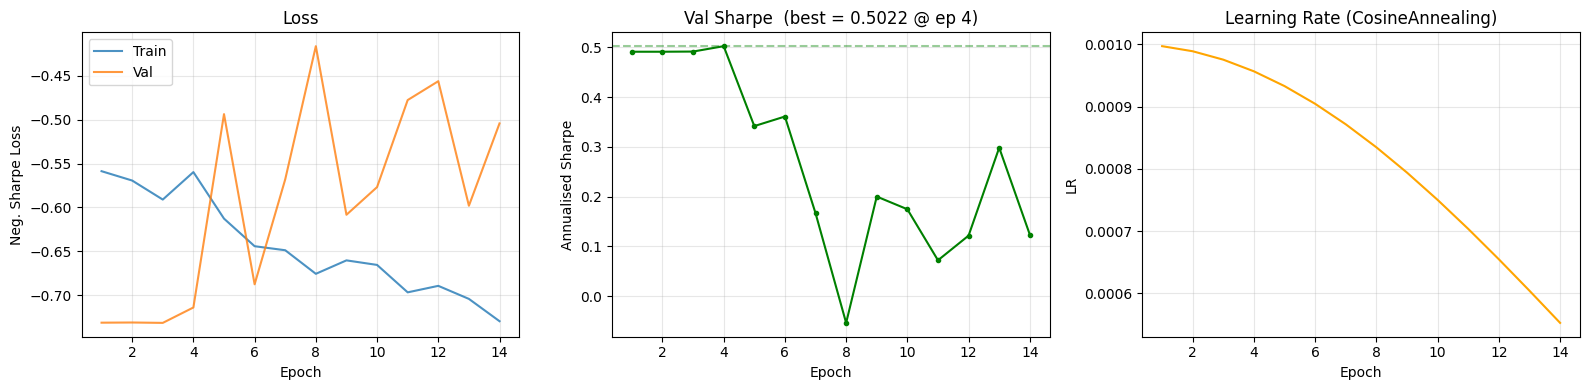

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Loss ──
axes[0].plot(history["epoch"], history["train_loss"], label="Train", alpha=0.8)
axes[0].plot(history["epoch"], history["val_loss"],   label="Val",   alpha=0.8)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Neg. Sharpe Loss")
axes[0].legend(); axes[0].set_title("Loss"); axes[0].grid(alpha=0.3)

# ── Validation Sharpe ──
axes[1].plot(history["epoch"], history["val_sharpe"], color="green", marker="o", markersize=3)
best_row = history.loc[history["val_sharpe"].idxmax()]
axes[1].axhline(best_row["val_sharpe"], ls="--", color="green", alpha=0.4)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Annualised Sharpe")
axes[1].set_title(f"Val Sharpe  (best = {best_row['val_sharpe']:.4f} @ ep {int(best_row['epoch'])})")
axes[1].grid(alpha=0.3)

# ── Learning Rate ──
axes[2].plot(history["epoch"], history["lr"], color="orange")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("LR")
axes[2].set_title("Learning Rate (CosineAnnealing)"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 3 — Evaluate & Backtest

In [9]:
# ── Test set evaluation ───────────────────────────────────────────────────
test_results = eval_epoch(
    model, loaders["test"], device, MODEL["warmup_steps"], _baseline_step
)

print(f"Test Sharpe Ratio:   {test_results['sharpe']:.4f}")
print(f"Test Max Drawdown:   {test_results['max_drawdown']:.4f}")
print(f"Test Loss:           {test_results['loss']:.4f}")
print(f"Test Trading Days:   {len(test_results['daily_returns'])}")

eval:   0%|          | 0/232 [00:00<?, ?it/s]

Test Sharpe Ratio:   1.5628
Test Max Drawdown:   -0.0832
Test Loss:           -1.4462
Test Trading Days:   707


In [10]:
# ── Run backtest (with and without transaction costs) ───────────────────
bt_gross = run_backtest(test_results["pred_df"], cost_bps=0.0,  label="Baseline DMN (gross)")
bt_5bps  = run_backtest(test_results["pred_df"], cost_bps=5.0,  label="Baseline DMN (5 bps)")
bt_10bps = run_backtest(test_results["pred_df"], cost_bps=10.0, label="Baseline DMN (10 bps)")

print_comparison([bt_gross, bt_5bps, bt_10bps])

                       gross_ann_return  gross_ann_vol  gross_sharpe  gross_max_dd  gross_calmar  gross_hit_rate  gross_days  net_ann_return  net_ann_vol  net_sharpe  net_max_dd  net_calmar  net_hit_rate  net_days  avg_turnover
model                                                                                                                                                                                                                              
Baseline DMN (gross)             0.1399         0.0862        1.5628       -0.0832        1.6804          0.5573         707          0.1399       0.0862      1.5628     -0.0832      1.6804        0.5573       707        0.0028
Baseline DMN (5 bps)             0.1399         0.0862        1.5628       -0.0832        1.6804          0.5573         707          0.1394       0.0862      1.5586     -0.0833      1.6743        0.5573       707        0.0028
Baseline DMN (10 bps)            0.1399         0.0862        1.5628       -0.0832      

,gross_ann_return,gross_ann_vol,gross_sharpe,gross_max_dd,gross_calmar,gross_hit_rate,gross_days,net_ann_return,net_ann_vol,net_sharpe,net_max_dd,net_calmar,net_hit_rate,net_days,avg_turnover
model,,,,,,,,,,,,,,,
Baseline DMN (gross),0.139854,0.086161,1.562762,-0.083224,1.680448,0.557284,707,0.139854,0.086161,1.562762,-0.083224,1.680448,0.557284,707,0.002838
Baseline DMN (5 bps),0.139854,0.086161,1.562762,-0.083224,1.680448,0.557284,707,0.139447,0.086160,1.558622,-0.083287,1.674299,0.557284,707,0.002838
Baseline DMN (10 bps),0.139854,0.086161,1.562762,-0.083224,1.680448,0.557284,707,0.139039,0.086160,1.554464,-0.083349,1.668160,0.557284,707,0.002838


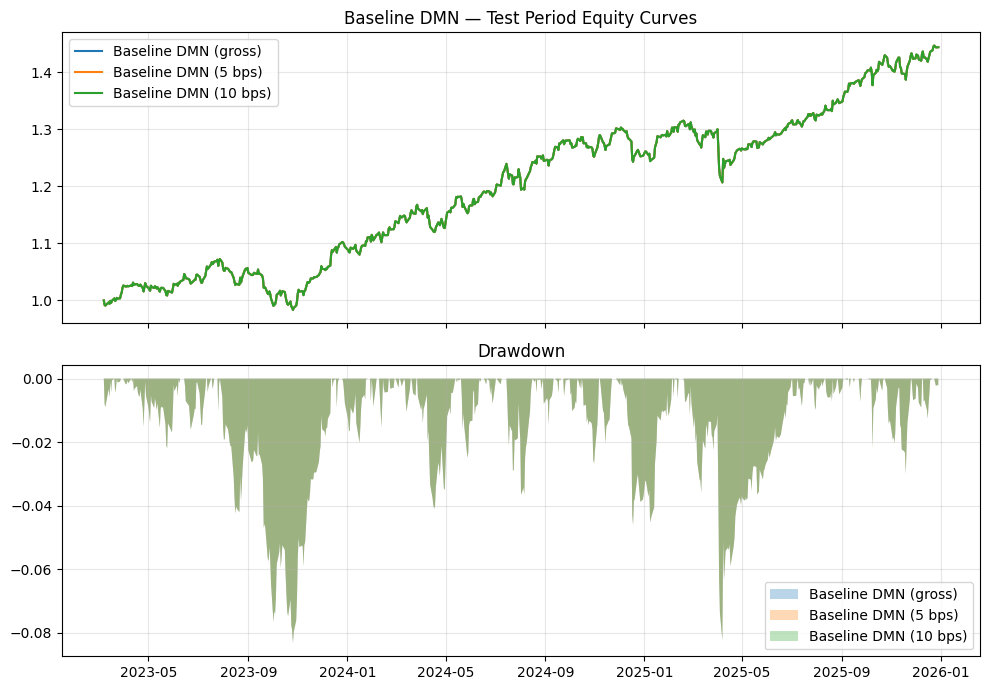

In [11]:
# ── Equity curves & drawdown ─────────────────────────────────────────────
fig = compare_equity(
    [bt_gross, bt_5bps, bt_10bps],
    "Baseline DMN \u2014 Test Period Equity Curves"
)
plt.show()

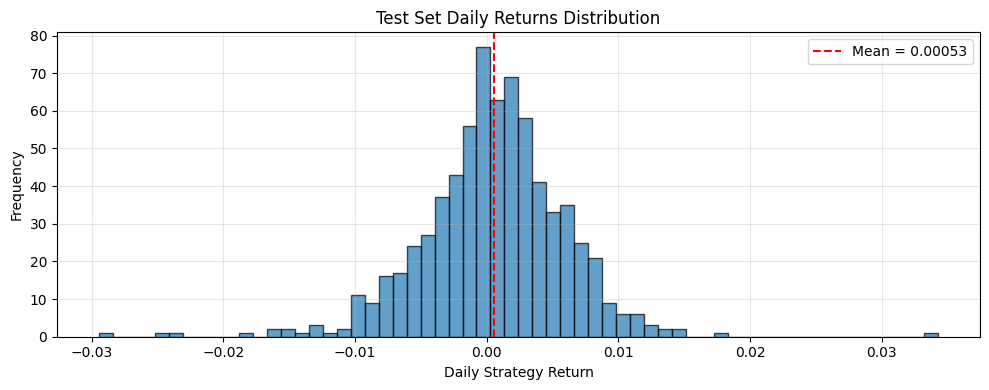

In [12]:
# ── Daily returns distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
daily = test_results["daily_returns"]
ax.hist(daily.values, bins=60, edgecolor="black", alpha=0.7)
ax.axvline(daily.mean(), color="red", ls="--", label=f"Mean = {daily.mean():.5f}")
ax.set_xlabel("Daily Strategy Return"); ax.set_ylabel("Frequency")
ax.set_title("Test Set Daily Returns Distribution"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## Step 4 — Save Results

In [ ]:
# ── Save model, predictions, and training history ──────────────────────
import os

OUT = "/content/results"
os.makedirs(OUT, exist_ok=True)

# Model weights
torch.save(model.state_dict(), f"{OUT}/baseline_dmn.pt")

# Test predictions (per-asset, per-day positions and returns)
test_results["pred_df"].to_csv(f"{OUT}/baseline_predictions.csv", index=False)

# Training history
history.to_csv(f"{OUT}/training_history.csv", index=False)

# Equity curve plot
fig = compare_equity([bt_gross], "Baseline DMN")
fig.savefig(f"{OUT}/equity_curve.png", dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"\u2705 Saved to {OUT}/:")
for f in sorted(os.listdir(OUT)):
    size = os.path.getsize(os.path.join(OUT, f))
    print(f"   {f:<30s}  ({size/1024:.1f} KB)")

In [ ]:
# ── Download results (optional) ───────────────────────────────────────────
# Uncomment to download files to your local machine:

# from google.colab import files
# files.download(f"{OUT}/baseline_dmn.pt")
# files.download(f"{OUT}/baseline_predictions.csv")
# files.download(f"{OUT}/training_history.csv")
# files.download(f"{OUT}/equity_curve.png")